<a href="https://colab.research.google.com/github/amathe1/Neural_Networks/blob/main/understanding_and_fixing_vanishing_grdient_issue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vanishing Gradient & Preventing Vanishing Gradient using Xavier weight initialization, Batch Normalization**

🎯 Goal

We will:

Build a deep sigmoid network → vanishing gradients
Measure gradient magnitudes

Fix with:
Xavier initialization
BatchNorm

Compare gradient flow visually

In [11]:
#Step1 - imports
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# importing two modules datasets, transforms from torchvision library
# 'datasets' is a module inside torchvision that gives ready-to-use datasets.
# 'transforms' is used to preprocess and modify images before feeding them into a neural network.
from torchvision import datasets, transforms

In [12]:
#Step2 - Load MNIST (real dataset)
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True,
                             download=True, transform=transform)

loader = torch.utils.data.DataLoader(train_data,
                                     batch_size=128,
                                     shuffle=True)

images, labels = next(iter(loader)) #  (batch_size, channels, height, width)

In [9]:
images.shape

torch.Size([128, 784])

In [13]:
"""
As per above shape of images : torch.Size([128, 1, 28, 28])
  - Our input data is in matrix format i.e. 28 * 28
  - ML model won't understand it. Hence we have to faltten this data.
  - Understand, we are dealing with Artificial Neural Network here. Hence we need to flatten the data into 0's and 1's for model to understand

"""
images = images.view(images.size(0), -1)  # Flatten

In [14]:
images

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [15]:
images.shape

torch.Size([128, 784])

In [16]:
#Vanishing gradient model (Deep Network + Sigmoid --> Classic Vanishing gradient)
class VanishingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784,256),
            nn.Sigmoid(),
            nn.Linear(256,256),
            nn.Sigmoid(),
            nn.Linear(256,256),
            nn.Sigmoid(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        return self.layers(x)


In [17]:
# Function to captured gradients

"""
| Part         | Meaning                           |
| ------------ | --------------------------------- |
| `param.grad` | gradient tensor                   |
| `.abs()`     | take absolute value (ignore sign) |
| `.mean()`    | average gradient value            |
| `.item()`    | convert tensor → Python number    |

"""
def get_gradients(model, data, target):
    criterion = nn.CrossEntropyLoss()
    output = model(data)
    loss = criterion(output,target)
    loss.backward()

    grads = []
    for name, param in model.named_parameters():
        if "weight" in name:
            grads.append(param.grad.abs().mean().item())

    return grads

In [18]:
#Train one step & collect gradients
model_bad = VanishingNet()
opt = optim.SGD(model_bad.parameters(), lr=0.1)

opt.zero_grad()
bad_grads = get_gradients(model_bad, images, labels)

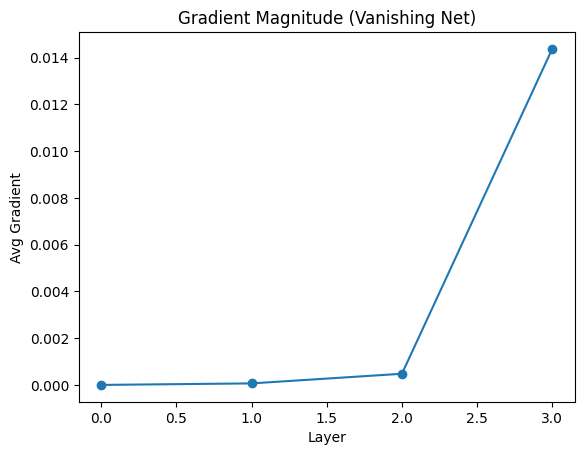

In [19]:
# Visualize vanishing gradients

plt.plot(bad_grads, marker='o')
plt.title("Gradient Magnitude (Vanishing Net)")
plt.xlabel("Layer")
plt.ylabel("Avg Gradient")
plt.show()

👉 You’ll see:

Early layers → extremely tiny gradients = Vanishing gradient problem

Fix Vanishing Gradients

We apply:

✅ Xavier Initialization

✅ Batch Normalization

✅ ReLU activation

Improved Model

In [20]:
class FixedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256,256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256,256)
        self.bn3 = nn.BatchNorm1d(256)

        self.fc4 = nn.Linear(256,10)

        self.relu = nn.ReLU()

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self,x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x

In [21]:
# Meaure gradients again
model_good = FixedNet()
opt = optim.SGD(model_good.parameters(), lr=0.1)

opt.zero_grad()
good_grads = get_gradients(model_good, images, labels)


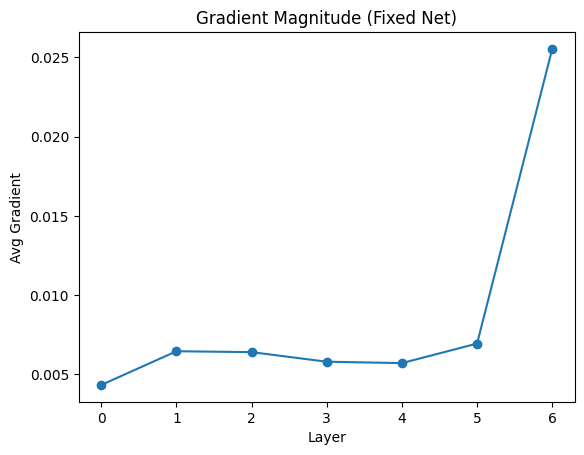

In [22]:
# Visualize improved gradient flow
plt.plot(good_grads, marker='o')
plt.title("Gradient Magnitude (Fixed Net)")
plt.xlabel("Layer")
plt.ylabel("Avg Gradient")
plt.show()


🧠 What You’ll Observe

BEFORE Fix

❌ Gradients shrink drastically

❌ Early layers almost zero

❌ Learning slows/stops

AFTER Fix

✅ Gradients stable across layers

✅ Faster learning

✅ Deep network trains properly